# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: mattanja gerritsen
* Username: mgerritsen
* Student number: s6325084
* Group (AS1, etc.): AS4

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt


hdul = fits.open("ngc6946.fits")
header = hdul[0].header
data = hdul[0].data

indices = range(1, 101, 2)

fig, axes = plt.subplots(5, 10, figsize=(15, 8), sharex=True, sharey=True)
fig.suptitle("HI Channel Maps (Z indices 1 to 101, step 2)")
for i, ax in enumerate(axes.flat):
    # data[indices[i]] accesses the specific velocity channel
    ax.imshow(data[indices[i]], origin='lower', cmap='viridis')
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

#channel maps

ctype1 = header.get('CTYPE1', 'Right Ascension')
ctype2 = header.get('CTYPE2', 'Declination')
ctype3 = header.get('CTYPE3', 'Velocity')
bunit = header.get('BUNIT', 'Intensity')

total_hi = np.sum(data[20:80], axis=0)
plt.figure(figsize=(8, 6))
plt.imshow(total_hi, origin='lower', cmap='magma')
plt.xlabel(ctype1)
plt.ylabel(ctype2)
plt.colorbar(label=bunit)
plt.title("Total HI Map")
plt.show()

pv_map = data[:, :, 50] 

plt.figure(figsize=(8, 6))
plt.imshow(pv_map, origin='lower', aspect='auto', cmap='jet')
plt.axvline(x=40, color='white', linestyle='--', label='Dec Index 40') # Vertical line at Dec 40
plt.xlabel(ctype2)
plt.ylabel(ctype3) 
plt.title("PV Map (at R.A. Index 50)")
plt.legend()
plt.show()


spectral_profile = data[:, 40, 50]

plt.figure(figsize=(8, 4))
plt.plot(spectral_profile, color='black')
plt.xlabel(ctype3)
plt.ylabel(bunit)
plt.title(f"Spectral Profile at R.A. 50, Dec 40")
plt.grid(True, alpha=0.3)
plt.show()
# The vertical line represents the data at the cordinate R = 50 and D = 40

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

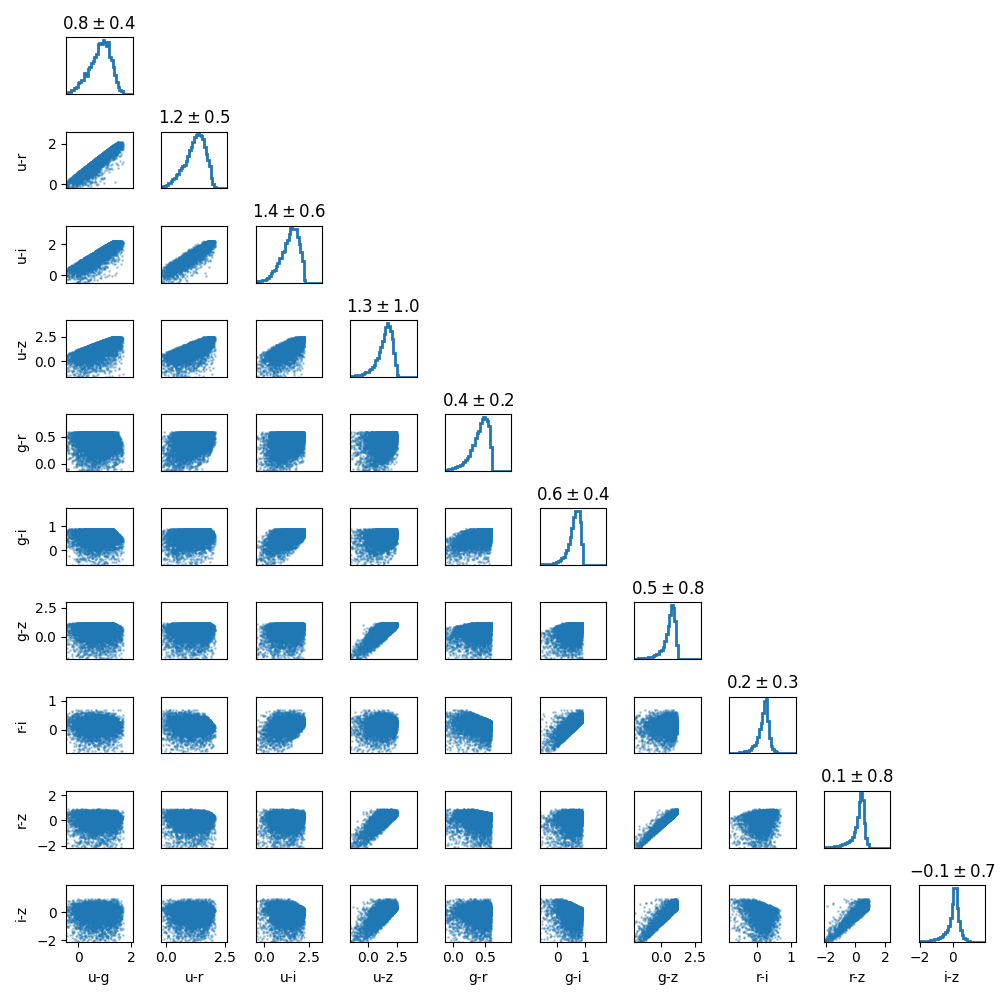
   
**Plot and answer**:

In [ ]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hdulist = fits.open('SDSS_DR17_galaxies.fits')
data = hdulist[1].data

df1 = pd.DataFrame(data)

df1 = df1[df1 > 0]

df1['ug'] = df1['u']-df1['g']; mean_ug = np.mean(df1['ug']); std_ug = np.std(df1['ug'])
df1['ur'] = df1['u']-df1['r']; mean_ur = np.mean(df1['ur']); std_ur = np.std(df1['ur'])
df1['ui'] = df1['u']-df1['i']; mean_ui = np.mean(df1['ui']); std_ui = np.std(df1['ui'])
df1['uz'] = df1['u']-df1['z']; mean_uz = np.mean(df1['uz']); std_uz = np.std(df1['uz'])
df1['gr'] = df1['g']-df1['r']; mean_gr = np.mean(df1['gr']); std_gr = np.std(df1['gr'])
df1['gi'] = df1['g']-df1['i']; mean_gi = np.mean(df1['gi']); std_gi = np.std(df1['gi'])
df1['gz'] = df1['g']-df1['z']; mean_gz = np.mean(df1['gz']); std_gz = np.std(df1['gz'])
df1['ri'] = df1['r']-df1['i']; mean_ri = np.mean(df1['ri']); std_ri = np.std(df1['ri'])
df1['rz'] = df1['r']-df1['z']; mean_rz = np.mean(df1['rz']); std_rz = np.std(df1['rz'])
df1['iz'] = df1['i']-df1['z']; mean_iz = np.mean(df1['iz']); std_iz = np.std(df1['iz'])


color_comb = ['ug', 'ur', 'ui', 'uz', 'gr', 'gi', 'gz', 'ri', 'rz', 'iz']  
n = len(color_comb) 
fig, frame = plt.subplots(n, n, figsize = (16, 14)) 
fig.tight_layout()

for i, ycol in enumerate(color_comb):
    for j, xcol in enumerate(color_comb):
        ax = frame[i, j]

        mu_x, sigma_x = df1[xcol].mean(), df1[xcol].std()

        if i < j:
            ax.axis("off")
            continue

        if i == j:
            ax.hist(df1[xcol].dropna(), bins=50, histtype='step', linewidth=2.0)
            ax.set_title(f"{mu_x:.1f} ± {sigma_x:.1f}")
            ax.set_xlim(mu_x - 3*sigma_x, mu_x + 3*sigma_x)

        else:
            mu_y, sigma_y = df1[ycol].mean(), df1[ycol].std()

            ax.scatter(df1[xcol], df1[ycol], s=1, alpha=0.5)
            ax.set_xlim(mu_x - 3*sigma_x, mu_x + 3*sigma_x)
            ax.set_ylim(mu_y - 3*sigma_y, mu_y + 3*sigma_y)

        if i == len(color_comb) - 1:
            ax.set_xlabel(xcol)
        if j == 0:
            ax.set_ylabel(ycol)
        if i != len(color_comb) - 1:
            ax.set_xticks([])
        if j != 0:
            ax.set_yticks([])
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

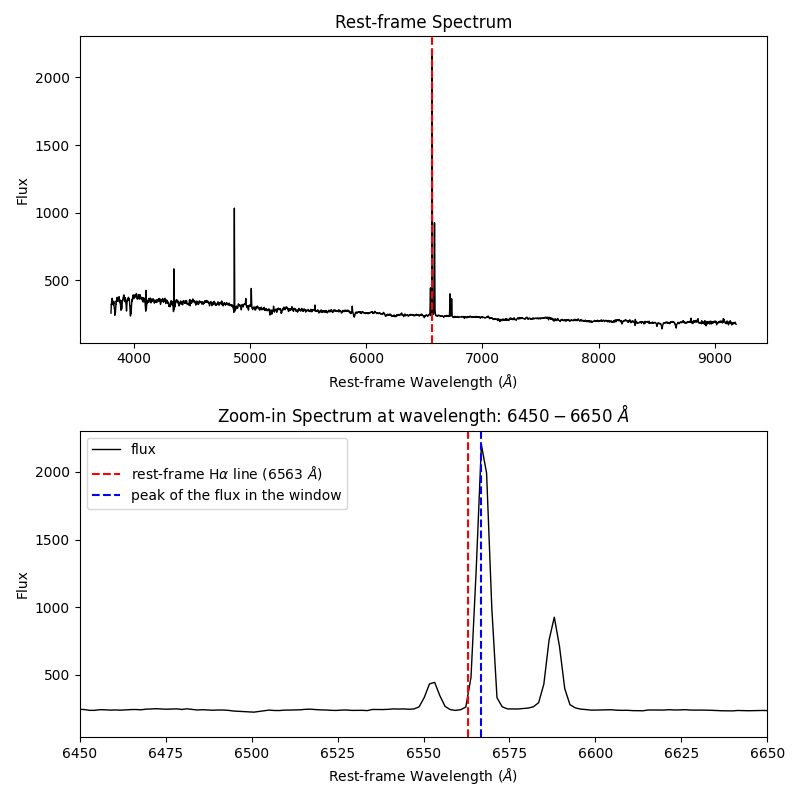

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import coordinates as coords
from astropy import units as u
from astroquery.sdss import SDSS

ra = 40.6696
dec = -0.0133
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

spec_table = SDSS.query_region(pos, radius=10 * u.arcsec, spectro=True)

hdulist = SDSS.get_spectra(matches=spec_table)
    
data = hdulist[0][1].data
flux = data['flux']
loglam = data['loglam']

wavelength_obs = 10**loglam
    

z = 0.0038
wavelength_rest = wavelength_obs / (1 + z)
    
h_alpha_rest = 6563.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
plt.subplots_adjust(hspace=0.3)

ax1.plot(wavelength_rest, flux, color='black', lw=1)
ax1.axvline(h_alpha_rest, color='red', linestyle='--')
ax1.set_title("Rest-frame Spectrum")
ax1.set_xlabel("Rest-frame Wavelength ($\\AA$)")
ax1.set_ylabel("Flux")

mask = (wavelength_rest >= 6450) & (wavelength_rest <= 6650)
w_zoom = wavelength_rest[mask]
f_zoom = flux[mask]

peak_idx = np.argmax(f_zoom)
peak_wavelength = w_zoom[peak_idx]
    
ax2.plot(w_zoom, f_zoom, color='black', lw=1, label='flux')
ax2.axvline(h_alpha_rest, color='red', linestyle='--', label=f'rest-frame H$\\alpha$ ({h_alpha_rest} $\\AA$)')
ax2.axvline(peak_wavelength, color='blue', linestyle='--', label='peak of the flux in the window')
    
ax2.set_xlim(6450, 6650)
ax2.set_title("Zoom-in Spectrum at wavelength: 6450 – 6650 $\\AA$")
ax2.set_xlabel("Rest-frame Wavelength ($\\AA$)")
ax2.set_ylabel("Flux")
ax2.legend()

plt.show()

c = 299792.458
delta_lambda = peak_wavelength - h_alpha_rest
velocity = c * (delta_lambda / h_alpha_rest)

print(f"Peak Wavelength observed in rest-frame: {peak_wavelength:.2f} Å")
print(f"Difference (Offset): {delta_lambda:.2f} Å")
print(f"Indicated Velocity: {velocity:.2f} km/s")


The Difference could be due to peculiar motian

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

In [ ]:
import numpy as np
from astropy.io import fits
import astropy.visualization
import matplotlib.pyplot as plt


def imdisplay(image, ax=None, stretch='linear', cmap='gray', vmin=None, vmax=None):

    if ax is None:
        ax = plt.gca()

    stretch = stretch.lower()
    if stretch == 'histeq':
        stretch_obj = astropy.visualization.HistEqStretch(image)
    else:
        stretch_map = {
            'linear': astropy.visualization.LinearStretch(),
            'log': astropy.visualization.LogStretch(),
            'sqrt': astropy.visualization.SqrtStretch(),
            'asinh': astropy.visualization.AsinhStretch(),
            'power': astropy.visualization.PowerStretch(2.0),
        }
        if stretch not in stretch_map:
            raise ValueError(f"Unknown stretch '{stretch}'. Choose from {list(stretch_map)} + ['histeq']")
        stretch_obj = stretch_map[stretch]

    if vmin is None or vmax is None:
        vmin, vmax = np.nanpercentile(image, [1, 99])

    norm = astropy.visualization.ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch_obj)
    im = ax.imshow(image, origin='lower', cmap=cmap, norm=norm)
    ax.set_title(f"{stretch}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    return im

fits_path = '20210422_Li_.00000066.FIT'
with fits.open(fits_path) as hdul:
    image_data = hdul[0].data

stretches = ['linear', 'log', 'sqrt', 'asinh', 'power', 'histeq']
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.ravel()

for ax, stretch in zip(axes, stretches):
    imdisplay(image_data, ax=ax, stretch=stretch, cmap='gray')

fig.suptitle('20210422_Li_.00000066.FIT - Scaling', fontsize=16)
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

datadir = "/Users/users/mgerritsen/DATA/" 
excludes = ['BIAS', 'FLAT', 'DARK']

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)

print(f"Found {len(filepaths)} images to stack.")


image_data_list = []
for file in filepaths:
    with fits.open(file) as hdul:
        data = hdul[0].data
        image_data_list.append(data.astype(np.float32))

stacked_image = np.median(image_data_list, axis=0)

plt.figure(figsize=(10, 8))
vmin, vmax = np.percentile(stacked_image, [1, 99])
plt.imshow(stacked_image, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
plt.colorbar(label='Intensity')
plt.title(f"Stacked Result of {len(filepaths)} Images")
plt.show()

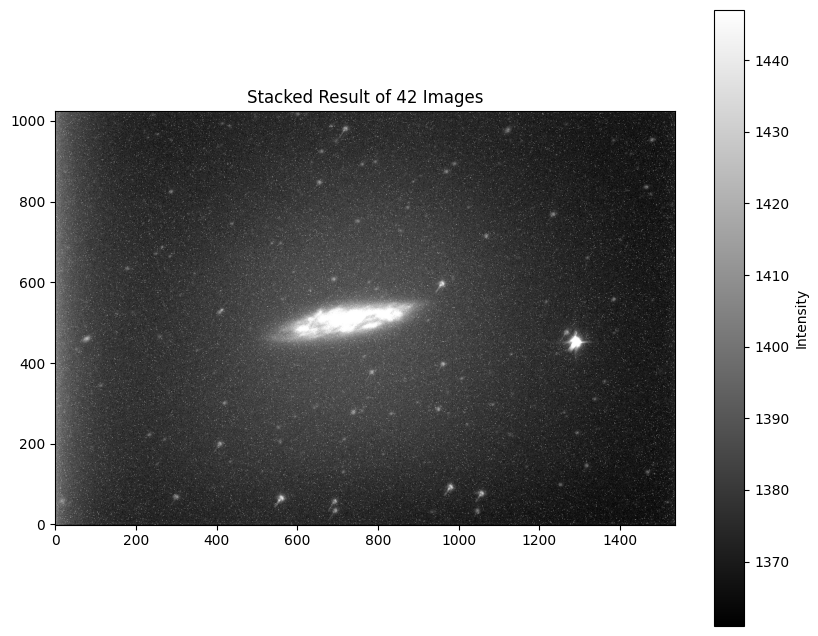

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")